In [1]:
from matplotlib.pyplot import rcParams

size = 20
params = {
          'figure.figsize': (10, 7),
          'legend.fontsize': size,
          'axes.labelsize': size,
          'xtick.labelsize': size,
          'ytick.labelsize': size,
         }
rcParams.update(params)

In [2]:
def meas_gen(n, generator):
    '''Creates operator to measurement stabilizer generator
    n [int]: Number of physical qubit in one logical qubit
    generator [list]: Stabilizer generator
    '''
    
    from qiskit import QuantumCircuit
    from qiskit.quantum_info import Operator
    
    # Create coresponding quantum circuit
    qc = QuantumCircuit(n + len(generator))
    qc.h(range(len(generator)))
    
    # Apply controlled gates
    for i in range(len(generator)):
        gen = generator[i]
        for j in range(len(generator[i])):
            if generator[i][j] == 'X':
                qc.cx(i, ~j)
            if generator[i][j] == 'Z':
                qc.cz(i, ~j)
    
    qc.h(range(len(generator)))
    return Operator(qc)

In [3]:
def damp_err(gamma, n):
    '''This method produces noise operators
    gamma [float]: Damping probability
    n [int]: Number of qubit
    '''
    
    if not isinstance(n, int) or n <= 0:
        raise ValueError(f"Number of qubit should be positive integer. Given {n}")
    if not isinstance(gamma, float) or gamma < 0 or gamma > 1:
        raise ValueError(f"Damping probability should lie between 0 and 1. Given {gamma}")
        
    from numpy import eye, zeros, kron, sqrt
    
    _E = [eye(2), zeros((2, 2))]
    _E[0][1][1] = sqrt(1-gamma)
    _E[1][0][1] = sqrt(gamma)
    
    E = _E.copy()#list(kron(_E, eye(2**(~-n)))/sqrt(n))
    for m in range(1, n):
        E_ = []
        for i in _E:
            for j in E:
                E_.append(kron(i, j))
        E = E_.copy()
#     E = list(kron(_E, eye(2**(~-n)))/sqrt(n))
#     for m in range(1, n):
#         E += list(kron(eye(2**m), kron(_E, eye(2**(~-n-m))))/sqrt(n))
    return E

In [4]:
def vec(A):
    '''This method vectorizes a matrix'''
    from numpy import matrix, concatenate, array
#     V = []
#     raise ValueError(A, matrix(concatenate(array(A), axis = None)).conjugate())
    return matrix(concatenate(array(A), axis = None)).conjugate()

In [5]:
class SDP:
    def __init__(self, num_qubit, gamma, state):
        '''
        num_qubit [int]: Number of physical qubit in one logical qubit
        gamma [float]: Damping probability
        state [list or numpy array]: Density matrix
        '''
        
        if not isinstance(num_qubit, int) or num_qubit <= 0:
            raise ValueError(f"Number of qubit should be positive integer. Given {num_qubit}")
        
        from numpy import array
        
        self.n = num_qubit
        self.noise_ops = damp_err(gamma, self.n)
        self.state = array(state)    #Input state
        self.X = None    #Variable
        self.constraints = None
        self.objective = None
        pass
    
    def solve(self, maximize):
        '''This method solves the SDP
        maximize [bool]: If True solves maximization problem, else solves minimization problem
        Returns: Optimal value
        '''
        
        if not isinstance(maximize, bool):
            raise TypeError('Not an optimization problem.')
        
        if maximize:
            from cvxpy import Problem, Maximize
            return Problem(Maximize(self.objective), self.constraints).solve()
        else:
            from cvxpy import Problem, Maximize
            return Problem(Minimize(self.objective), self.constraints).solve()

In [6]:
class five_qubit_code:
    def __init__(self):
        self.num_qubit = 5
        self.generator = ['XZZXI', 'IXZZX', 'XIXZZ', 'ZXIXZ']    #Stabilizer generator
        self.L0 = [0, 18, 9, 20, 10, -27, -6, -24, -29, -3, -30, -15, -17, -12, -23, 5]    #Logical 0
        self.L1 = [31, 13, 22, 11, 21, -4, -25, -7, -2, -28, -1, -16, -14, -19, -8, 26]    #Logical 1
        self.enc_op = self._get_enc_op()    #Encoding operator
        self.codebook = {0: 'IIIII', 1: 'IXIII', 2: 'IIIIZ', 3: 'IIXII', 4: 'IIZII', 5: 'ZIIII', 6: 'IIIXI',
                         7: 'IIYII', 8: 'XIIII', 9: 'IIIZI', 10: 'IZIII', 11: 'IYIII', 12: 'IIIIX', 13: 'YIIII',
                         14: 'IIIIY', 15: 'IIIYI'}    #Syndrome measurement: Correction
        self.synd_op = meas_gen(5, self.generator)    #Syndrome measurement operator
        self.cor_op = None    #Correction operator
        pass
    
    def _get_enc_op(self):
        '''Creates Encoding operator'''
        
        from numpy import zeros, transpose, sqrt
        from qiskit.quantum_info import Operator
        
        # Operator is initially zero
        enc_op = zeros((2, 2**self.num_qubit))
        
        # Put 1 and -1 depending on L0 and L1
        # if i in Lj, (j, abs(i))-th element of the operator will be 1 if i is no-negative and -1 otherwise
        for i in self.L0:
            v = 1/sqrt(len(self.L0))
            if i != abs(i):
                v = -v
            enc_op[0][abs(i)] = v
        for i in self.L1:
            v = 1/sqrt(len(self.L1))
            if i != abs(i):
                v = -v
            enc_op[1][abs(i)] = v
        return Operator(transpose(enc_op))
    
    def _get_cor_op(self, synd_res):
        '''Creates correction operation
        synd_res [str]: Syndrome measurement result
        '''
        
        from qiskit.quantum_info import Operator, Pauli
        self.cor_op = Operator(Pauli(self.codebook[int(synd_res, 2)]))
        pass
    
    def run(self, state, gamma):
        '''Executes the QEC
        state [list or numpy array]: Density matrix
        gamma [float]: Damping probability
        Returns: Corrected state
        '''
        
        from qiskit.quantum_info import Kraus, DensityMatrix, partial_trace
        from numpy import transpose
        
        # Encode the state
        state = DensityMatrix(state).evolve(self.enc_op)
        
        # Apply noise
        noise_ops = Kraus(damp_err(gamma, self.num_qubit))
        state = state.evolve(noise_ops)
        
        # Syndrome measurement
        anc = [1] + [0] * ~-(2**len(self.generator))
        state = DensityMatrix(anc).expand(state).evolve(self.synd_op)
        synd_res, state = state.measure(range(len(self.generator)))
        state = partial_trace(state, range(len(self.generator)))
        
        # Apply correction operation
        self._get_cor_op(synd_res)
        state = state.evolve(self.cor_op)
        
        # Decode the state
        state = state.evolve(self.enc_op.transpose())    #Decoding operation is conjugate transpose of Encoding op.
        return state
    
    def run_SDP(self, gamma, state):
        '''Executes the QEC with SDP
        state [list or numpy array]: Density matrix
        gamma [float]: Damping probability
        Returns: Optimal fidelity
        '''
        
        from cvxpy import partial_trace, trace, real, Variable
        from numpy import eye, kron, transpose, matrix
        
        # Construct SDP
        prob = SDP(self.num_qubit, gamma, state)
        
        # Define variable
        prob.X = Variable((2**(prob.n<<1), 2**(prob.n<<1)), hermitian=True)
        
        # Define constraints
        prob.constraints = [prob.X >> 0, partial_trace(prob.X, (2**prob.n, 2**prob.n), 1) == eye(2**prob.n)]
        
        # Define objective function
        Cv = []
        anc = [1] + [0] * ~-(2**~-prob.n)
        s_v = kron(prob.state, anc)
        sv = [[i] for i in s_v]
        for noise in prob.noise_ops:
            Cv.append(vec(sv@matrix(prob.state)@self.enc_op.transpose().data@transpose(noise)))
        C = Cv[0].getH().dot(Cv[0])
        for c in Cv[1:]:
            C += c.getH().dot(c)
        prob.objective = real(trace(prob.X@C))
        
        return prob.solve(True)

In [7]:
class four_qubit_code:
    def __init__(self):
        self.num_qubit = 4
        self.L0 = [0, 15]    #Logical 0
        self.L1 = [3, 12]    #Logical 1
        self.enc_op = self._get_enc_op()    #Encoding operator
        self.synd_op = self._get_synd_op()    #Syndrome measurement operator
        self.cor_op = None    #Correction operator
        pass
    
    def _get_enc_op(self):
        '''Creates Encoding operator'''
        
        from numpy import zeros, transpose, sqrt
        from qiskit.quantum_info import Operator
        
        # Operator is initially zero
        enc_op = zeros((2, 2**self.num_qubit))
        
        # Put 1 and -1 depending on L0 and L1
        # if i in Lj, (j, abs(i))-th element of the operator will be 1 if i is no-negative and -1 otherwise
        for i in self.L0:
            v = 1/sqrt(len(self.L0))
            if i != abs(i):
                v = -v
            enc_op[0][abs(i)] = v
        for i in self.L1:
            v = 1/sqrt(len(self.L1))
            if i != abs(i):
                v = -v
            enc_op[1][abs(i)] = v
        return Operator(transpose(enc_op))
    
    def _get_synd_op(self):
        '''Creates syndrome measurement operation'''
        
        from qiskit import QuantumCircuit
        from qiskit.quantum_info import Operator
        
        # Create corresponding quantum circuit
        qc = QuantumCircuit(self.num_qubit)
        
        # Apply CNOT gates
        qc.cx([0, 2], [1, 3])
        
        return Operator(qc)
    
    def _get_cor_op(self, gamma):
        '''Creates correction operation
        gamma [float]: Damping probability
        '''
        
        from numpy import arctan, arccos, pi
        from qiskit import QuantumCircuit
        from qiskit.quantum_info import Operator
        
        self.cor_op = []
        for i in range(3):
            if not i:
                theta = arctan((1-gamma)**2)
                qc = QuantumCircuit(2)
                qc.cx(1, 0)
                qc.ry(2*theta, 1)
                qc.cry(pi/2-2*theta, 0, 1)
                self.cor_op.append(Operator(qc))
            elif not ~-i:
                theta = arccos(1-gamma)
                qc = QuantumCircuit(3)
                qc.x(2)
                qc.cry(theta, 2, 0)
                self.cor_op.append(Operator(qc))
            elif not ~-~-i:
                theta = arccos(1-gamma)
                qc = QuantumCircuit(3)
                qc.x(1)
                qc.cry(theta, 1, 0)
                self.cor_op.append(Operator(qc))
        pass
    
    def run(self, state, gamma):
        '''Executes the QEC
        state [list or numpy array]: Density matrix
        gamma [float]: Damping probability
        Returns: Corrected state
        '''
        
        from qiskit.quantum_info import Kraus, DensityMatrix, partial_trace
        
        # Encode the state
        state = DensityMatrix(state).evolve(self.enc_op)
        
        # Apply noise
        noise_ops = Kraus(damp_err(gamma, self.num_qubit))
        state = state.evolve(noise_ops)
        
        # Syndrome measurement
        synd_res, state = state.evolve(self.synd_op).measure([1, 3])
        state = partial_trace(state, [1, 3])
        
        # Apply correction operation
        self._get_cor_op(gamma)
        if not int(synd_res, 2):
            state = state.evolve(self.cor_op[int(synd_res, 2)])
            state = partial_trace(state.measure([1])[1], [1])
        elif not ~-int(synd_res, 2):
            state = DensityMatrix([1, 0]).expand(state).evolve(self.cor_op[int(synd_res, 2)])
            state = partial_trace(state.measure([0])[1], [0, 1])
        elif not ~-~-int(synd_res, 2):
            state = DensityMatrix([1, 0]).expand(state).evolve(self.cor_op[int(synd_res, 2)])
            state = partial_trace(state.measure([0])[1], [0, 2])
        
        return state
    
    def run_SDP(self, gamma, state):
        '''Executes the QEC with SDP
        state [list or numpy array]: Density matrix
        gamma [float]: Damping probability
        Returns: Optimal fidelity
        '''
        
        from cvxpy import partial_trace, trace, real, Variable
        from numpy import eye, kron, transpose, matrix\
        
        # Construct SDP
        prob = SDP(self.num_qubit, gamma, state)
        
        # Define variable
        prob.X = Variable((2**(prob.n<<1), 2**(prob.n<<1)), hermitian=True)
        
        # Define constraints
        prob.constraints = [prob.X >> 0, partial_trace(prob.X, (2**prob.n, 2**prob.n), 1) == eye(2**prob.n)]
        
        # Define objective function
        Cv = []
        anc = [1] + [0] * ~-(2**~-prob.n)
        s_v = kron(prob.state, anc)
        sv = [[i] for i in s_v]
        for noise in prob.noise_ops:
            Cv.append(vec(sv@matrix(prob.state)@self.enc_op.transpose().data@transpose(noise)))
        C = Cv[0].getH().dot(Cv[0])
        for c in Cv[1:]:
            C += c.getH().dot(c)
        prob.objective = real(trace(prob.X@C))
        
        return prob.solve(True)

In [10]:
from qiskit.quantum_info import DensityMatrix, random_statevector, state_fidelity
from numpy import trace, matmul, sqrt

NUM = 1#000
num_qubit = 1
damp_params = [i/20 for i in range(11)]
fid_QEC5 = [0 for _ in range(len(damp_params))]
fid_SDP5 = [0 for _ in range(len(damp_params))]
fid_QEC4 = [0 for _ in range(len(damp_params))]
fid_SDP4 = [0 for _ in range(len(damp_params))]
fid_sing = [0 for _ in range(len(damp_params))]
states = [[1/sqrt(2), 1/sqrt(2)]]#random_statevector(2).data for _ in range(NUM)]

for rho in states:
    for i in range(len(damp_params)):
        print(f'{-~i} out of {len(damp_params)}', end = '\r')
        QEC4 = four_qubit_code()
        fid_QEC4[i] += state_fidelity(DensityMatrix(rho), QEC4.run(DensityMatrix(rho), damp_params[i]))/NUM
        fid_SDP4[i] += QEC4.run_SDP(damp_params[i], rho)/NUM
        
        QEC5 = five_qubit_code()
        fid_QEC5[i] += state_fidelity(DensityMatrix(rho), QEC5.run(DensityMatrix(rho), damp_params[i]))/NUM
        fid_SDP5[i] += QEC5.run_SDP(damp_params[i], rho)/NUM
        
        E = damp_err(damp_params[i], 1)
        A = matmul(DensityMatrix(rho), E[0])
        for e in E[1:]:
            A += matmul(rho, e)
        fid_sing[i] += abs(trace(A))**2/NUM

ValueError: shapes (2,2) and (4,4) not aligned: 2 (dim 1) != 4 (dim 0)

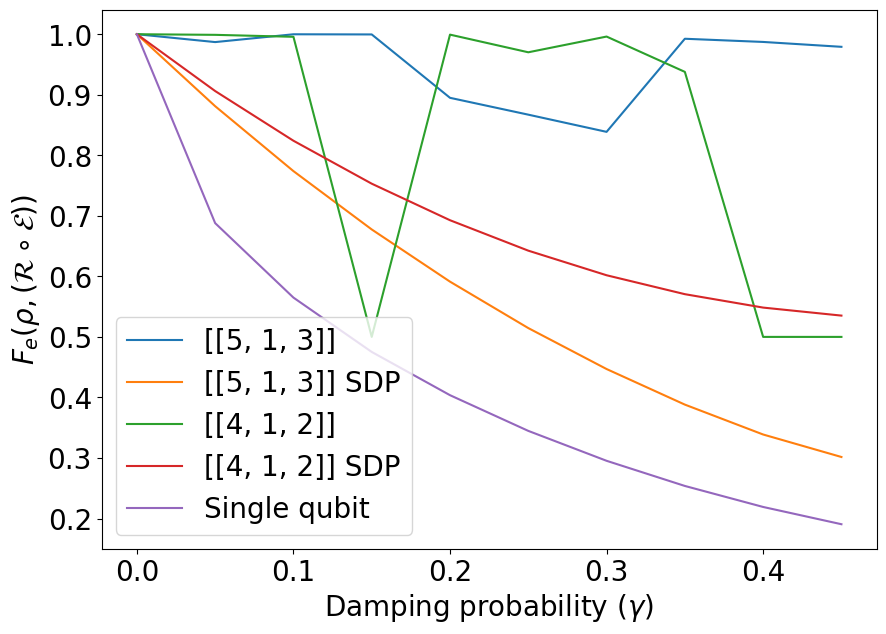

In [14]:
from matplotlib.pyplot import subplots, legend, savefig, show

_, ax = subplots(1, 1)
ax.plot(damp_params[:-1], fid_QEC5[:-1], label = "[[5, 1, 3]]")
ax.plot(damp_params[:-1], fid_SDP5[:-1], label = "[[5, 1, 3]] SDP")
ax.plot(damp_params[:-1], fid_QEC4[:-1], label = "[[4, 1, 2]]")
ax.plot(damp_params[:-1], fid_SDP4[:-1], label = "[[4, 1, 2]] SDP")
ax.plot(damp_params[:-1], [2-i for i in fid_sing[:-1]], label = "Single qubit")
# ax.plot([gamma/10 for gamma in range(6)], fidnc, label = "Single qubit")
# ax.plot([gamma/10 for gamma in range(6)], fid1, label = "Excited state")
ax.set_xlabel(r'Damping probability $(\gamma)$')
ax.set_ylabel(r'$F_e(\rho,(\mathcal{R}\circ\mathcal{E}))$')
legend()
show()